In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, r2_score

In [141]:
data = pd.read_csv("taxi_trip_pricing.csv")
data

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


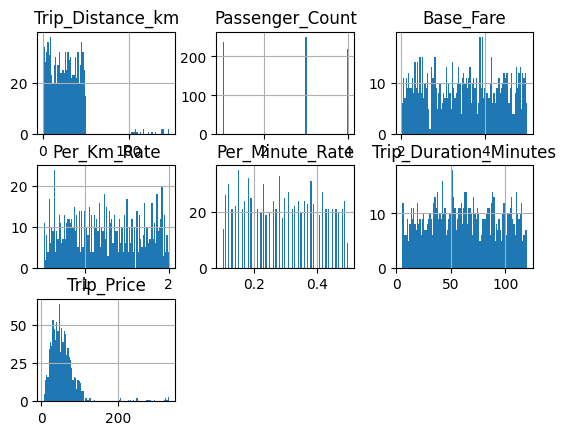

In [142]:
data.hist(bins=100);

In [143]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    str    
 2   Day_of_Week            950 non-null    str    
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    str    
 5   Weather                950 non-null    str    
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), str(4)
memory usage: 86.1 KB


In [144]:
data.isna().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [145]:
media = data['Trip_Distance_km'].median()
data['Trip_Distance_km'] = data['Trip_Distance_km'].fillna(media)

In [146]:
counts = data["Time_of_Day"].value_counts(normalize=True, dropna=False)
data["Time_of_Day"] = data["Time_of_Day"].apply(lambda x: np.random.choice(counts.keys(), p=counts.values) if pd.isna(x) else x)

In [147]:
data.isna().sum()

Trip_Distance_km          0
Time_of_Day               5
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [148]:
counts = data["Time_of_Day"].value_counts()

In [149]:
for v in counts.keys():
    data[f"Time_of_Day_{v}"] = (data["Time_of_Day"] == v).astype("int8")
data.drop("Time_of_Day", axis=1, inplace=True)

In [150]:
data

,Trip_Distance_km,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Afternoon,Time_of_Day_Morning,Time_of_Day_Evening,Time_of_Day_Night
0,19.35,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624,0,1,0,0
1,47.59,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN,1,0,0,0
2,36.87,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032,0,0,1,0
3,30.33,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698,0,0,1,0
4,25.83,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049,1,0,0,0
996,45.95,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295,0,0,0,1
997,7.70,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236,0,1,0,0
998,47.56,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090,0,1,0,0


In [151]:
data["Day_of_Week"] = (data["Day_of_Week"] == "Weekday").astype("int8")

In [152]:
data

,Trip_Distance_km,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Afternoon,Time_of_Day_Morning,Time_of_Day_Evening,Time_of_Day_Night
0,19.35,1,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624,0,1,0,0
1,47.59,1,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN,1,0,0,0
2,36.87,0,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032,0,0,1,0
3,30.33,1,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698,0,0,1,0
4,25.83,1,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,0,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049,1,0,0,0
996,45.95,1,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295,0,0,0,1
997,7.70,1,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236,0,1,0,0
998,47.56,1,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090,0,1,0,0


In [153]:
media = data["Passenger_Count"].median()
data["Passenger_Count"] = data["Passenger_Count"].fillna(media)

In [154]:
counts = data["Traffic_Conditions"].value_counts(normalize=True)
data["Traffic_Conditions"] = data["Traffic_Conditions"].apply(lambda x: np.random.choice(counts.keys(), p=counts.values) if pd.isna(x) else x)
for v in counts.keys():
    data[f"Traffic_Conditions_{v}"] = (data["Traffic_Conditions"] == v).astype("int8")
data.drop("Traffic_Conditions", axis=1, inplace=True)

In [155]:
data

,Trip_Distance_km,Day_of_Week,Passenger_Count,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Afternoon,Time_of_Day_Morning,Time_of_Day_Evening,Time_of_Day_Night,Traffic_Conditions_Low,Traffic_Conditions_Medium,Traffic_Conditions_High
0,19.35,1,3.0,Clear,3.56,0.80,0.32,53.82,36.2624,0,1,0,0,1,0,0
1,47.59,1,1.0,Clear,NaN,0.62,0.43,40.57,NaN,1,0,0,0,0,0,1
2,36.87,0,1.0,Clear,2.70,1.21,0.15,37.27,52.9032,0,0,1,0,0,0,1
3,30.33,1,4.0,NaN,3.48,0.51,0.15,116.81,36.4698,0,0,1,0,1,0,0
4,25.83,1,3.0,Clear,2.93,0.63,0.32,22.64,15.6180,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,0,4.0,Clear,2.39,0.62,0.49,58.39,34.4049,1,0,0,0,0,1,0
996,45.95,1,4.0,Clear,3.12,0.61,NaN,61.96,62.1295,0,0,0,1,0,1,0
997,7.70,1,3.0,Rain,2.08,1.78,NaN,54.18,33.1236,0,1,0,0,1,0,0
998,47.56,1,1.0,Clear,2.67,0.82,0.17,114.94,61.2090,0,1,0,0,1,0,0


In [156]:
data.isna().sum()

Trip_Distance_km              0
Day_of_Week                   0
Passenger_Count               0
Weather                      50
Base_Fare                    50
Per_Km_Rate                  50
Per_Minute_Rate              50
Trip_Duration_Minutes        50
Trip_Price                   49
Time_of_Day_Afternoon         0
Time_of_Day_Morning           0
Time_of_Day_Evening           0
Time_of_Day_Night             0
Traffic_Conditions_Low        0
Traffic_Conditions_Medium     0
Traffic_Conditions_High       0
dtype: int64

In [157]:
counts = data["Weather"].value_counts(normalize=True, dropna=False)
data["Weather"] = data["Weather"].apply(lambda x: np.random.choice(counts.keys(), p=counts.values) if pd.isna(x) else x)

In [158]:
data["Weather"] = data["Weather"].apply(lambda x: np.random.choice(counts.keys(), p=counts.values) if pd.isna(x) else x)
for v in counts.keys():
    data[f"Weather_{v}"] = (data["Weather"] == v).astype("int8")
data.drop("Weather", axis=1, inplace=True)

In [159]:
median = data["Base_Fare"].median()
data["Base_Fare"] = data["Base_Fare"].fillna(median)

In [160]:
median = data["Per_Km_Rate"].median()
data["Per_Km_Rate"] = data["Per_Km_Rate"].fillna(median)

In [161]:
median = data["Per_Minute_Rate"].median()
data["Per_Minute_Rate"] = data["Per_Minute_Rate"].fillna(median)

In [162]:
median = data["Trip_Duration_Minutes"].median()
data["Trip_Duration_Minutes"] = data["Trip_Duration_Minutes"].fillna(median)

In [163]:
median = data["Trip_Price"].median()
data["Trip_Price"] = data["Trip_Price"].fillna(median)

In [164]:
# data["Trip_Distance_km"] = np.log(data["Trip_Distance_km"]).hist(bins=100)

In [165]:
x = data.drop("Trip_Price", axis=1)
y = data["Trip_Price"].values

In [166]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [167]:
sc = MinMaxScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [168]:
y_train = np.log(y_train)
y_test = np.log(y_test)

In [178]:
model = LinearRegression()
model.fit(x_train, y_train)
y_train_pred_log = model.predict(x_train)
y_test_pred_log = model.predict(x_test)

y_train_orig = np.exp(y_train)
y_test_orig = np.exp(y_test)
y_train_pred = np.exp(y_train_pred_log)
y_test_pred = np.exp(y_test_pred_log)

print(f"Train MAE: {mean_absolute_error(y_train_orig, y_train_pred)}")
print(f"Test MAE: {mean_absolute_error(y_test_orig, y_test_pred)}")
print(f"R2: {r2_score(y_test_orig, y_test_pred)}")


Train MAE: 10.231272271782487
Test MAE: 6.991117279620155
R2: 0.8915443738200057


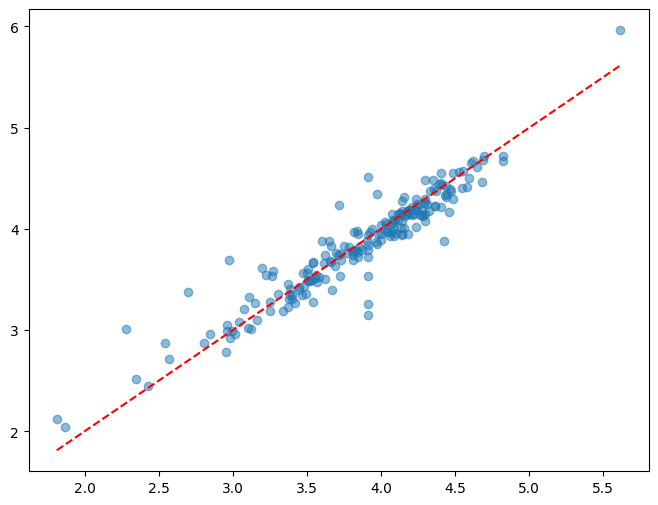

In [184]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')

In [187]:
model = LinearRegression()
poly = PolynomialFeatures(degree=2, include_bias=False)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)
model.fit(x_train_poly, y_train)
y_train_pred = model.predict(x_train_poly)
y_test_pred = model.predict(x_test_poly)
print(f"Train: {mean_absolute_error(y_train, y_train_pred)}, Test: {mean_absolute_error(y_test, y_test_pred)}, R2: {r2_score(y_test, y_test_pred)}")

Train: 0.11135952689107174, Test: 0.11890593363837464, R2: 0.8948378673007275


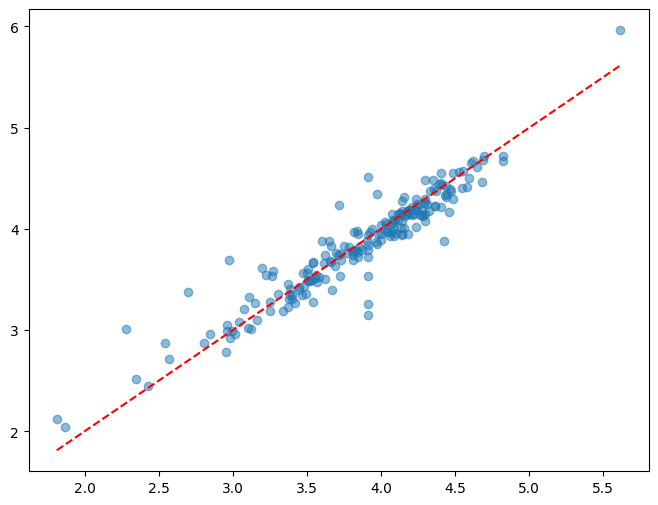

In [188]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')